In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (10000, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

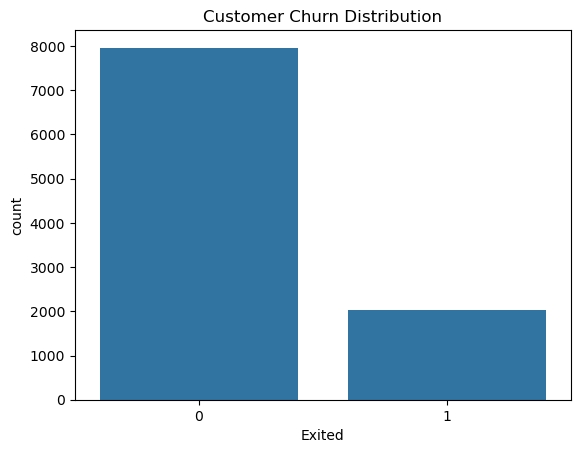

In [8]:
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [9]:
df.drop(
    columns=["RowNumber", "CustomerId", "Surname"],
    inplace=True
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
print(df["Gender"].unique())
print(df["Geography"].unique())

['Female' 'Male']
['France' 'Spain' 'Germany']


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Geography"] = le.fit_transform(df["Geography"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [12]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 10)
(10000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8155

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8645
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [19]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import sys
print(sys.executable)
print(sys.version)

C:\ProgramData\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [21]:
import xgboost
print(xgboost.__version__)

3.2.0


In [22]:
from xgboost import XGBClassifier
print("XGBoost loaded successfully!")

XGBoost loaded successfully!


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8695
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.74      0.51      0.61       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [24]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- -----------

In [25]:
import shap
print(shap.__version__)

0.52.0


In [26]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

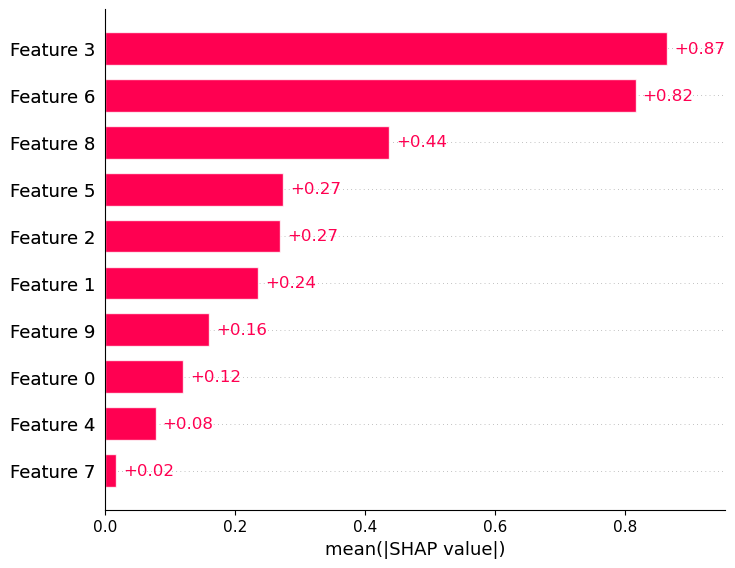

In [27]:
shap.plots.bar(shap_values)

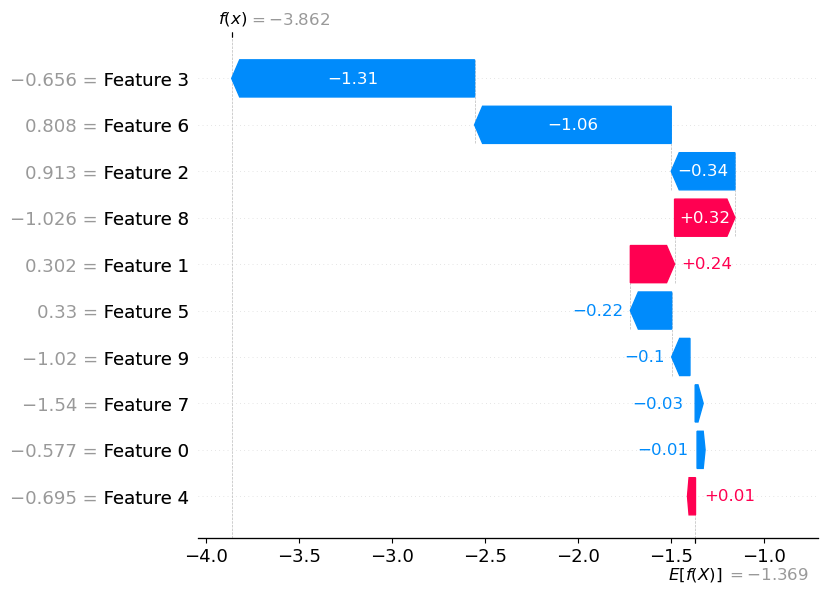

In [28]:
shap.plots.waterfall(shap_values[0])

In [29]:
probs = xgb.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual": y_test.values,
    "Churn_Probability": probs
})

risk_df.head()

,Actual,Churn_Probability
0,0,0.020587
1,0,0.023263
2,0,0.077995
3,0,0.169836
4,0,0.104226


In [30]:
def risk_level(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df["Risk_Level"] = risk_df[
    "Churn_Probability"
].apply(risk_level)

risk_df.head(10)

,Actual,Churn_Probability,Risk_Level
0,0,0.020587,Low Risk
1,0,0.023263,Low Risk
2,0,0.077995,Low Risk
3,0,0.169836,Low Risk
4,0,0.104226,Low Risk
5,0,0.010466,Low Risk
6,0,0.075813,Low Risk
7,1,0.235910,Low Risk
8,0,0.245520,Low Risk
9,0,0.427839,Medium Risk


In [31]:
def recommendation(risk):
    if risk == "High Risk":
        return "Offer discount and premium support"
    elif risk == "Medium Risk":
        return "Provide loyalty rewards"
    else:
        return "No action required"

risk_df["Recommendation"] = risk_df[
    "Risk_Level"
].apply(recommendation)

risk_df.head(10)

,Actual,Churn_Probability,Risk_Level,Recommendation
0,0,0.020587,Low Risk,No action required
1,0,0.023263,Low Risk,No action required
2,0,0.077995,Low Risk,No action required
3,0,0.169836,Low Risk,No action required
4,0,0.104226,Low Risk,No action required
5,0,0.010466,Low Risk,No action required
6,0,0.075813,Low Risk,No action required
7,1,0.235910,Low Risk,No action required
8,0,0.245520,Low Risk,No action required
9,0,0.427839,Medium Risk,Provide loyalty rewards


In [32]:
random_customer = X_test[0].reshape(1, -1)

prediction = xgb.predict(random_customer)
probability = xgb.predict_proba(random_customer)[0][1]

print("Prediction:", prediction[0])
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: 0
Churn Probability: 2.06 %
